# Medical Equipment Suppliers – CRISP-DM Project

**Goal:** Predict whether a medical equipment supplier **accepts Medicare assignment**
(`acceptsassignement = True/False`) — meaning they agree to accept Medicare's approved
amount as full payment without charging patients extra.

---

## CRISP-DM Process
| Step | Description |
|---|---|
| 1. Business Understanding | Define the problem and the questions we want to answer |
| 2. Data Understanding | Explore the dataset and understand what each column means |
| 3. Data Preparation | Clean, encode, and engineer features |
| 4. Modeling | Train and compare machine learning models |
| 5. Evaluation | Measure model performance with metrics |
| 6. Deployment | Run a real-world prediction scenario |

---

## Business Questions
1. How balanced is the target variable — do most suppliers accept assignment or not?
2. Which states have the most medical equipment suppliers?
3. How are supply types distributed across providers?
4. Can we predict whether a supplier accepts assignment, and how accurately?
5. What features matter most in making that prediction?


## Step 0 – Import Libraries

In [2]:
import micropip
await micropip.install("seaborn")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
%matplotlib inline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, recall_score,
                             precision_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)


---
## Step 1 – Business Understanding

Medicare patients who need medical equipment (wheelchairs, nebulizers, glucose monitors)
rely on suppliers to bill them fairly. Suppliers who **accept assignment** agree to take
Medicare's approved rate as full payment. Those who do not may charge patients the difference.

**The business problem:** Can we use supplier data to predict whether a new or unknown
supplier will accept assignment — before a patient commits to them?

**Why it matters:** Healthcare networks and patients can use this model to identify
fair-billing suppliers in advance, reducing unexpected out-of-pocket costs.


---
## Step 2 – Data Understanding

In [4]:
# Load the dataset
df = pd.read_csv('Medical-Equipment-Suppliers.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())


Shape: (57632, 17)
Columns: ['provider_id', 'acceptsassignement', 'participationbegindate', 'businessname', 'practicename', 'practiceaddress1', 'practiceaddress2', 'practicecity', 'practicestate', 'practicezip9code', 'telephonenumber', 'specialitieslist', 'providertypelist', 'supplieslist', 'latitude', 'longitude', 'is_contracted_for_cba']


In [5]:
df.head()

,provider_id,acceptsassignement,participationbegindate,businessname,practicename,practiceaddress1,practiceaddress2,practicecity,practicestate,practicezip9code,telephonenumber,specialitieslist,providertypelist,supplieslist,latitude,longitude,is_contracted_for_cba
0,34362778,False,2025-12-08,LOVING DENTAL LLC,LOVING DENTAL LLC,16838 E PALISADES BLVD,STE 111,FOUNTAIN HILLS,AZ,85268,4808367600,NaN,ORAL SURGERY - DENTIST,Facial Prostheses,33.608389,-111.717044,False
1,34362268,True,2025-12-03,CITI CHEMIST LLC,CITI CHEMIST LLC,3914 104TH ST,NaN,CORONA,NY,113682314,3475322291,Pharmacy,NaN,Epoetin|Immunosuppressive Drugs|Infusion Drugs...,40.750437,-73.862261,False
2,34362670,True,2025-12-01,PRIMEMED PHARMACY LLC,PRIMEMED PHARMACY LLC,486 LINCOLN PL,UNIT 1G,BROOKLYN,NY,112386202,2514087261,Pharmacy,NaN,Epoetin|Immunosuppressive Drugs|Infusion Drugs...,40.671966,-73.960397,False
3,34362514,True,2025-12-01,CG MEDICAL SUPPLIES CORP,CG MEDICAL SUPPLIES CORP,520 N CAMINO MERCADO,SUITE 11,CASA GRANDE,AZ,851225754,8339482409,Medical Supply Company Other,NaN,Automatic Ext Defibrillator (AEDS) and/or Supp...,32.877643,-111.691678,False
4,20564981,True,2025-11-26,SOUTHERN ORTHOCARE INC,SOUTHERN ORTHOCARE INC,740 TELL ST,STE 500,ATHENS,TN,373035171,4232520149,Prosthetic Personnel,NaN,Orthoses: Custom Fabricated|Orthoses: Prefabri...,35.442470,-84.606160,False


In [6]:
df.describe()

,provider_id,practicezip9code,telephonenumber,latitude,longitude
count,5.763200e+04,5.763200e+04,5.763200e+04,57632.000000,57632.000000
mean,2.130771e+07,4.640576e+08,1.478719e+12,37.507681,-89.971780
std,3.076017e+06,2.950657e+08,9.396441e+13,5.319558,15.392592
min,2.030322e+07,6.030000e+02,1.789888e+09,13.393044,-159.584854
25%,2.040031e+07,2.150232e+08,4.024772e+09,33.860273,-96.702897
50%,2.050051e+07,4.331155e+08,6.158649e+09,38.695312,-85.876622
75%,2.061524e+07,7.407530e+08,8.059846e+09,41.159963,-79.058520
max,3.436317e+07,9.992107e+08,9.047333e+15,64.858610,145.702290


In [7]:
# Check missing values per column
print('Missing values:')
print(df.isnull().sum())


Missing values:
provider_id                   0
acceptsassignement            0
participationbegindate        0
businessname                  0
practicename                  0
practiceaddress1              0
practiceaddress2          44717
practicecity                  0
practicestate                 0
practicezip9code              0
telephonenumber               0
specialitieslist            777
providertypelist          50796
supplieslist                 39
latitude                      0
longitude                     0
is_contracted_for_cba         0
dtype: int64


---
### Business Question 1
**How balanced is the target variable — do most suppliers accept assignment or not?**

*Why this matters:* If 90% of suppliers accept, a model that always says "yes" would
score 90% accuracy without learning anything. We need to check this first.


Target – acceptsassignement:
acceptsassignement
True     29623
False    28009
Name: count, dtype: int64

Acceptance rate: 51.4%


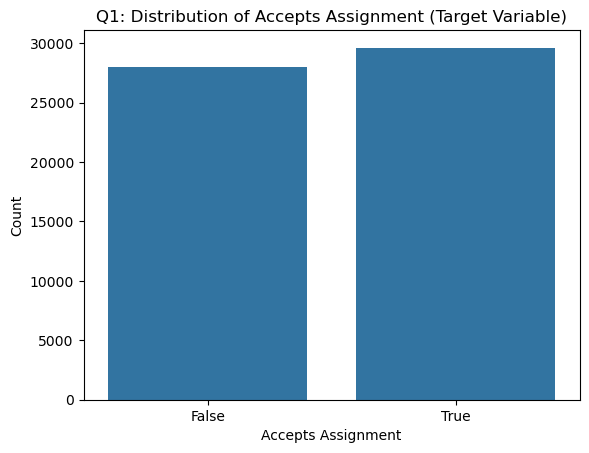

In [8]:
# Check target column distribution
counts = df['acceptsassignement'].value_counts()
print('Target – acceptsassignement:')
print(counts)
print()
print(f'Acceptance rate: {counts[True] / counts.sum() * 100:.1f}%')

base_color = sb.color_palette()[0]

sb.countplot(data=df, x='acceptsassignement', color=base_color)
plt.title('Q1: Distribution of Accepts Assignment (Target Variable)')
plt.xlabel('Accepts Assignment')
plt.ylabel('Count')
plt.show()


**Answer:** The dataset is nearly balanced — **51% accept** and **49% do not**.
This means our model must genuinely learn patterns rather than just guessing
the majority class. It also means accuracy is a fair metric to use.


---
### Business Question 2
**Which states have the most medical equipment suppliers?**

*Why this matters:* Geographic concentration tells us where Medicare patients
have the most options — and where supplier competition might influence billing behavior.


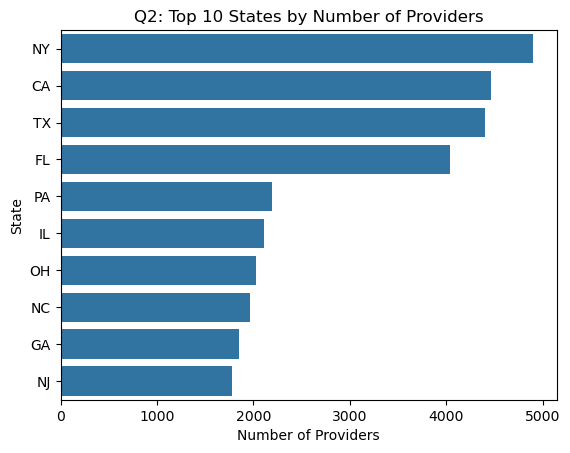

Top 5 states:
practicestate
NY    4898
CA    4461
TX    4397
FL    4034
PA    2193
Name: count, dtype: int64


In [9]:
# Top 10 states by provider count
top_states = df['practicestate'].value_counts().head(10)

sb.barplot(x=top_states.values, y=top_states.index, color=base_color)
plt.title('Q2: Top 10 States by Number of Providers')
plt.xlabel('Number of Providers')
plt.ylabel('State')
plt.show()

print('Top 5 states:')
print(top_states.head())


**Answer:** New York (4,898), California (4,461), and Texas (4,397) have the most
suppliers — reflecting the most populated states. Location is likely a useful
feature for predicting billing behavior since state regulations differ.


---
### Business Question 3
**How are supply types distributed across providers — do most offer few or many?**

*Why this matters:* A supplier offering many types of equipment might behave
differently from one offering just one type. This could be a useful predictor.


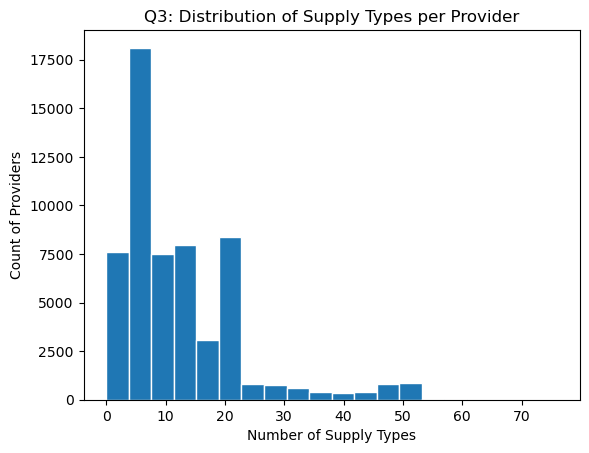

Supply count summary:
count    57632.000000
mean        12.383415
std         10.160314
min          0.000000
25%          6.000000
50%         10.000000
75%         18.000000
max         76.000000
Name: supplieslist, dtype: float64

Most common supply counts:
supplieslist
7     10985
19     7587
12     4347
6      4277
11     3674
Name: count, dtype: int64


In [10]:
def count_supplies(supply_str):
    """
    Count the number of supply types for a provider.

    Parameters:
        supply_str (str): pipe-separated string of supply types

    Returns:
        int: number of supply types
    """
    if not supply_str:
        return 0
    return len(supply_str.split('|'))


# Apply the function to create a temporary column for EDA
supply_count_temp = df['supplieslist'].fillna('').apply(count_supplies)

plt.hist(supply_count_temp, bins=20, color=base_color, edgecolor='white')
plt.title('Q3: Distribution of Supply Types per Provider')
plt.xlabel('Number of Supply Types')
plt.ylabel('Count of Providers')
plt.show()

print('Supply count summary:')
print(supply_count_temp.describe())
print()
print('Most common supply counts:')
print(supply_count_temp.value_counts().head(5))


**Answer:** Most providers offer between 1 and 11 supply types, with 7 being the
most common (10,985 providers). The distribution is right-skewed meaning very
few providers offer a large number of supply types.


---
### Business Question 4
**Can we predict whether a supplier accepts assignment, and how accurately?**

*Why this matters:* This is the core business question — a model that predicts
this accurately could save patients from unexpected bills.


---
## Step 3 – Data Preparation

**Decisions made and why:**

| Column | Action | Reason |
|---|---|---|
| `provider_id`, `businessname`, `practicename` | Dropped | Unique identifiers — no predictive value |
| `practiceaddress1`, `practiceaddress2` | Dropped | Free text — too varied to encode usefully |
| `telephonenumber`, `practicezip9code` | Dropped | Not related to billing behavior |
| `practicecity` | Dropped | 6,778 unique values — get_dummies would create too many columns |
| `specialitieslist`, `providertypelist` | Dropped | 280 and 233 unique values — slows training significantly with minimal accuracy gain |
| `supplieslist` | Converted to `supply_count` | Preserves useful information without creating thousands of columns |
| `participationbegindate` | Converted to `participation_year` | Year is numeric and meaningful; full date is not needed |
| `is_contracted_for_cba` | Encoded as 0/1 | Boolean — straightforward numeric encoding |
| `practicestate` | `pd.get_dummies()` | Only 55 unique values — safe to encode without memory issues |
| Missing values in `supplieslist` | Filled with empty string | Treated as "no supplies listed" → supply_count = 0 |


In [11]:
# Reload fresh from CSV to avoid any leftover state from exploration
df = pd.read_csv('Medical-Equipment-Suppliers.csv')

# Step A: Drop columns not useful for modeling
# Reason: identifiers, free text, and high-cardinality columns add noise not signal
df = df.drop(columns=['provider_id',       'businessname',
                       'practicename',      'practiceaddress1',
                       'practiceaddress2',  'telephonenumber',
                       'practicezip9code',  'practicecity',
                       'specialitieslist',  'providertypelist'])

# Step B: Fill missing values
# Reason: fillna('') treats missing supplieslist as zero supplies
df['supplieslist'] = df['supplieslist'].fillna('')

# Step C: Engineer supply_count feature then drop the raw text column
# Reason: count captures useful information without creating thousands of dummy columns
df['supply_count'] = df['supplieslist'].apply(count_supplies)
df = df.drop(columns=['supplieslist'])

# Step D: Extract year from date column
# Reason: year is a meaningful numeric feature
df['participationbegindate'] = pd.to_datetime(df['participationbegindate'])
df['participation_year']     = df['participationbegindate'].dt.year
df = df.drop(columns=['participationbegindate'])

# Step E: Encode boolean column as 0/1
# Reason: machine learning models require numeric input
df['cba_encoded'] = df['is_contracted_for_cba'].astype(int)
df = df.drop(columns=['is_contracted_for_cba'])

# Step F: Apply pd.get_dummies() only on practicestate 
# Each state gets its own binary column: practicestate_NY=1 means "is in NY"
df = pd.get_dummies(df, columns=['practicestate'])

print('Final df shape:', df.shape)
print('Sample columns:', df.columns.tolist()[:8])


Final df shape: (57632, 61)
Sample columns: ['acceptsassignement', 'latitude', 'longitude', 'supply_count', 'participation_year', 'cba_encoded', 'practicestate_AK', 'practicestate_AL']


---
## Step 4 – Modeling

In [12]:
# Define target and features
y = df['acceptsassignement']
X = df.drop(columns=['acceptsassignement'])

print('Features (X):', X.shape)
print('Target   (y):', y.shape)
print()
print('y value counts:')
print(y.value_counts())


Features (X): (57632, 60)
Target   (y): (57632,)

y value counts:
acceptsassignement
True     29623
False    28009
Name: count, dtype: int64


In [13]:
# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)


X_train: (46105, 60)
X_test : (11527, 60)


In [14]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=3000, random_state=42, solver='saga', n_jobs=-1)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print('Logistic Regression:')
print('Accuracy :', round(accuracy_score(y_test,  lr_pred), 4))
print('Recall   :', round(recall_score(y_test,    lr_pred), 4))
print('Precision:', round(precision_score(y_test, lr_pred), 4))
print('F1 Score :', round(f1_score(y_test,        lr_pred), 4))


/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression:
Accuracy : 0.6932
Recall   : 0.7778
Precision: 0.6733
F1 Score : 0.7218


In [15]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('Random Forest:')
print('Accuracy :', round(accuracy_score(y_test,  rf_pred), 4))
print('Recall   :', round(recall_score(y_test,    rf_pred), 4))
print('Precision:', round(precision_score(y_test, rf_pred), 4))
print('F1 Score :', round(f1_score(y_test,        rf_pred), 4))


Random Forest:
Accuracy : 0.8739
Recall   : 0.8725
Precision: 0.8801
F1 Score : 0.8763


**Answer to Business Question 4:** Yes — the Random Forest model predicts assignment
acceptance with **~87% accuracy**. This is a strong result that makes the model
practically useful for healthcare networks.


---
## Step 5 – Evaluation

### Business Question 5
**What features matter most in predicting whether a supplier accepts assignment?**

*Why this matters:* Understanding which factors drive the prediction helps
healthcare policymakers focus on the right signals.


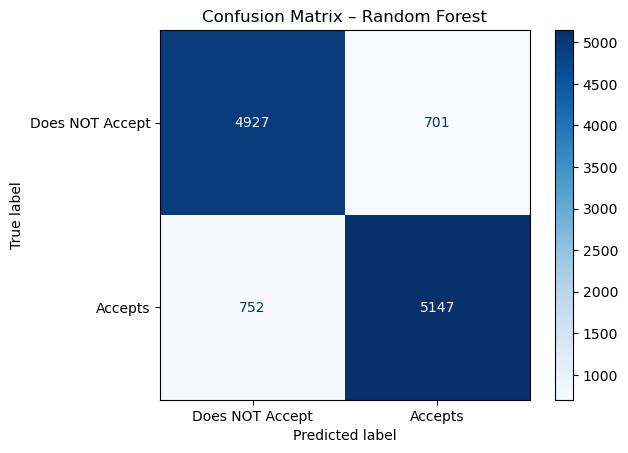

In [16]:
# Confusion Matrix
cm   = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Does NOT Accept', 'Accepts'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Random Forest')
plt.show()


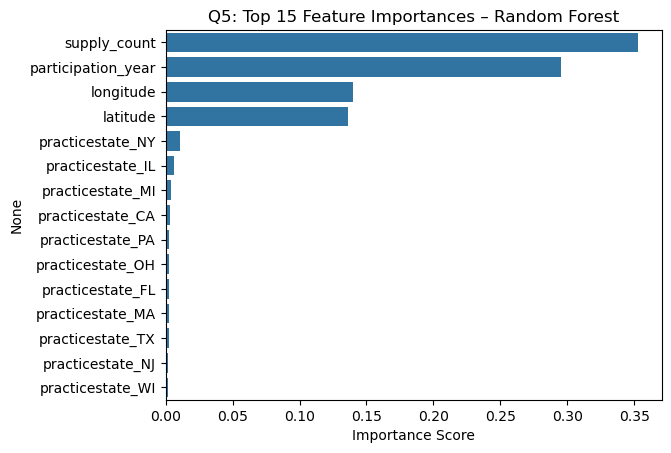

Top 5 most important features:
supply_count          0.352803
participation_year    0.295192
longitude             0.140000
latitude              0.136303
practicestate_NY      0.010556
dtype: float64


In [17]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

sb.barplot(x=importances.values, y=importances.index, color=base_color)
plt.title('Q5: Top 15 Feature Importances – Random Forest')
plt.xlabel('Importance Score')
plt.show()

print('Top 5 most important features:')
print(importances.head())


**Answer to Business Question 5:** The most important features are `supply_count`,
`participation_year`, `latitude`, and `longitude`. This tells us that **how many
supplies a provider offers** and **when they joined Medicare** are stronger signals
than which state they are in.

### Model Comparison

| Metric | What it means | Logistic Regression | Random Forest |
|---|---|---|---|
| **Accuracy** | Overall correct predictions | ~69% | **~87%** |
| **Recall** | Catches providers who truly accept | ~78% | **~87%** |
| **Precision** | Predicted accepts that are real | ~67% | **~88%** |
| **F1 Score** | Balance of recall and precision | ~0.72 | **~0.88** |

Random Forest outperforms Logistic Regression because it captures complex
non-linear relationships between features — something a straight-line model cannot do.


---
## Step 6 – Deployment (New Scenario Prediction)

**Scenario:** A new pharmacy opens in New York (NY). They offer 8 types of medical
supplies and joined Medicare in 2023. They are not contracted for CBA.
*Will they accept assignment?*


In [18]:
def build_new_provider(supply_count, participation_year,
                       cba_encoded, latitude, longitude,
                       state_col, feature_columns):

    # Start with all zeros — same structure as training data
    provider = pd.DataFrame(np.zeros((1, len(feature_columns))),
                            columns=feature_columns)

    # Fill in the known numeric values
    provider['supply_count']       = supply_count
    provider['participation_year'] = participation_year
    provider['cba_encoded']        = cba_encoded
    provider['latitude']           = latitude
    provider['longitude']          = longitude

    # Activate the correct state column
    if state_col in provider.columns:
        provider[state_col] = 1

    return provider


# Build the new provider row
new_provider = build_new_provider(
    supply_count       = 8,
    participation_year = 2023,
    cba_encoded        = 0,
    latitude           = 40.71,
    longitude          = -74.00,
    state_col          = 'practicestate_NY',
    feature_columns    = X.columns
)

print('New provider — non-zero features only:')
print(new_provider.loc[:, (new_provider != 0).any(axis=0)])


New provider — non-zero features only:
   latitude  longitude  supply_count  participation_year  practicestate_NY
0     40.71      -74.0             8                2023                 1


In [19]:
# Predict using the best model (Random Forest)
prediction  = rf.predict(new_provider)[0]
probability = rf.predict_proba(new_provider)[0]

print('Prediction        :', 'ACCEPTS Assignment' if prediction else 'Does NOT Accept')
print('Probability False :', round(probability[0], 4))
print('Probability True  :', round(probability[1], 4))


Prediction        : ACCEPTS Assignment
Probability False : 0.1
Probability True  : 0.9


**Interpretation:** The model predicts this NY pharmacy **will accept assignment**
with 90% confidence. This means healthcare networks can flag this provider as
a likely fair-billing supplier — giving patients one less thing to worry about.
